## High Performance Rainfall Prediction

Data source: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package

### Importing Libraries

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

import tensorflow as tf

from sklearn.metrics import f1_score

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('weatherAUS.csv')
data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
data = data.drop('Date', axis=1)

In [5]:
data

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


### Preprocessing

In [6]:
df = data.copy()

In [7]:
df.isnull().sum()

Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [8]:
df.dtypes

Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [9]:
missing_target_rows = df.loc[df['RainTomorrow'].isna(),:].index
missing_target_rows

Index([    14,    283,    435,    437,    443,    452,    455,    464,    611,
          983,
       ...
       144908, 144925, 144937, 144949, 144950, 144955, 145091, 145092, 145335,
       145459],
      dtype='int64', length=3267)

In [10]:
# Dropping missing target rows
df = df.drop(missing_target_rows, axis=0).reset_index(drop=True)

In [11]:
df.isna().sum()

Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RainTomorrow         0
dtype: int64

In [12]:
df['RainToday'].unique()

array(['No', 'Yes', nan], dtype=object)

In [13]:
df['RainToday'] = df['RainToday'].fillna('No')

In [14]:
df['Location'].unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [15]:
encoder = LabelEncoder()

label_encoder_columns = ['RainToday', 'RainTomorrow']

for column in label_encoder_columns:
    df[column] = encoder.fit_transform(df[column])

In [16]:
df['RainToday'].unique()

array([0, 1])

In [17]:
df.dtypes

Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday          int64
RainTomorrow       int64
dtype: object

In [18]:
df['WindGustDir'].unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', 'ENE', 'SSE',
       'S', 'NW', 'SE', 'ESE', nan, 'E', 'SSW'], dtype=object)

In [19]:
df['WindDir9am'].unique()

array(['W', 'NNW', 'SE', 'ENE', 'SW', 'SSE', 'S', 'NE', nan, 'SSW', 'N',
       'WSW', 'ESE', 'E', 'NW', 'WNW', 'NNE'], dtype=object)

In [20]:
df['WindDir3pm'].unique()

array(['WNW', 'WSW', 'E', 'NW', 'W', 'SSE', 'ESE', 'ENE', 'NNW', 'SSW',
       'SW', 'SE', 'N', 'S', 'NNE', nan, 'NE'], dtype=object)

In [21]:
def add_column_prefixes(df, column, prefix):
    return df[column].apply(lambda x: prefix + str(x))

In [22]:
df['Location'] = add_column_prefixes(df, 'Location', 'Loc_')

In [23]:
df['WindGustDir'] = add_column_prefixes(df, 'WindGustDir', 'WGD_')
df['WindDir9am'] = add_column_prefixes(df, 'WindDir9am', 'WD9_')
df['WindDir3pm'] = add_column_prefixes(df, 'WindDir3pm', 'WD3_')

In [24]:
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Loc_Albury,13.4,22.9,0.6,NaN,NaN,WGD_W,44.0,WD9_W,WD3_WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0
1,Loc_Albury,7.4,25.1,0.0,NaN,NaN,WGD_WNW,44.0,WD9_NNW,WD3_WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0
2,Loc_Albury,12.9,25.7,0.0,NaN,NaN,WGD_WSW,46.0,WD9_W,WD3_WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0
3,Loc_Albury,9.2,28.0,0.0,NaN,NaN,WGD_NE,24.0,WD9_SE,WD3_E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0
4,Loc_Albury,17.5,32.3,1.0,NaN,NaN,WGD_W,41.0,WD9_ENE,WD3_NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,Loc_Uluru,3.5,21.8,0.0,NaN,NaN,WGD_E,31.0,WD9_ESE,WD3_E,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,0,0
142189,Loc_Uluru,2.8,23.4,0.0,NaN,NaN,WGD_E,31.0,WD9_SE,WD3_ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,0,0
142190,Loc_Uluru,3.6,25.3,0.0,NaN,NaN,WGD_NNW,22.0,WD9_SE,WD3_N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,0,0
142191,Loc_Uluru,5.4,26.9,0.0,NaN,NaN,WGD_N,37.0,WD9_SE,WD3_WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,0,0


In [25]:
def onehot_encoder(df, columns):
    df = df.copy()
    for column in columns:
        dummies = pd.get_dummies(df[column])
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

In [26]:
categorical_columns = ['Location', 'WindGustDir', 'WindDir3pm', 'WindDir9am']

df = onehot_encoder(df, categorical_columns)

In [27]:
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Loc_Adelaide,Loc_Albany,Loc_Albury,Loc_AliceSprings,Loc_BadgerysCreek,Loc_Ballarat,Loc_Bendigo,Loc_Brisbane,Loc_Cairns,Loc_Canberra,Loc_Cobar,Loc_CoffsHarbour,Loc_Dartmoor,Loc_Darwin,Loc_GoldCoast,Loc_Hobart,Loc_Katherine,Loc_Launceston,Loc_Melbourne,Loc_MelbourneAirport,Loc_Mildura,Loc_Moree,Loc_MountGambier,Loc_MountGinini,Loc_Newcastle,Loc_Nhil,Loc_NorahHead,Loc_NorfolkIsland,Loc_Nuriootpa,Loc_PearceRAAF,Loc_Penrith,Loc_Perth,Loc_PerthAirport,Loc_Portland,Loc_Richmond,Loc_Sale,Loc_SalmonGums,Loc_Sydney,Loc_SydneyAirport,Loc_Townsville,Loc_Tuggeranong,Loc_Uluru,Loc_WaggaWagga,Loc_Walpole,Loc_Watsonia,Loc_Williamtown,Loc_Witchcliffe,Loc_Wollongong,Loc_Woomera,WGD_E,WGD_ENE,WGD_ESE,WGD_N,WGD_NE,WGD_NNE,WGD_NNW,WGD_NW,WGD_S,WGD_SE,WGD_SSE,WGD_SSW,WGD_SW,WGD_W,WGD_WNW,WGD_WSW,WGD_nan,WD3_E,WD3_ENE,WD3_ESE,WD3_N,WD3_NE,WD3_NNE,WD3_NNW,WD3_NW,WD3_S,WD3_SE,WD3_SSE,WD3_SSW,WD3_SW,WD3_W,WD3_WNW,WD3_WSW,WD3_nan,WD9_E,WD9_ENE,WD9_ESE,WD9_N,WD9_NE,WD9_NNE,WD9_NNW,WD9_NW,WD9_S,WD9_SE,WD9_SSE,WD9_SSW,WD9_SW,WD9_W,WD9_WNW,WD9_WSW,WD9_nan
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0

In [28]:
df.columns[df.dtypes == 'object']

Index([], dtype='object')

In [30]:
missing_value_columns = df.columns[df.isna().sum() > 0]
missing_value_columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

In [31]:
# Filling missing values with mean
for column in missing_value_columns:
    df[column] = df[column].fillna(df[column].mean())

In [32]:
df.isna().sum().sum()

np.int64(0)

In [33]:
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Loc_Adelaide,Loc_Albany,Loc_Albury,Loc_AliceSprings,Loc_BadgerysCreek,Loc_Ballarat,Loc_Bendigo,Loc_Brisbane,Loc_Cairns,Loc_Canberra,Loc_Cobar,Loc_CoffsHarbour,Loc_Dartmoor,Loc_Darwin,Loc_GoldCoast,Loc_Hobart,Loc_Katherine,Loc_Launceston,Loc_Melbourne,Loc_MelbourneAirport,Loc_Mildura,Loc_Moree,Loc_MountGambier,Loc_MountGinini,Loc_Newcastle,Loc_Nhil,Loc_NorahHead,Loc_NorfolkIsland,Loc_Nuriootpa,Loc_PearceRAAF,Loc_Penrith,Loc_Perth,Loc_PerthAirport,Loc_Portland,Loc_Richmond,Loc_Sale,Loc_SalmonGums,Loc_Sydney,Loc_SydneyAirport,Loc_Townsville,Loc_Tuggeranong,Loc_Uluru,Loc_WaggaWagga,Loc_Walpole,Loc_Watsonia,Loc_Williamtown,Loc_Witchcliffe,Loc_Wollongong,Loc_Woomera,WGD_E,WGD_ENE,WGD_ESE,WGD_N,WGD_NE,WGD_NNE,WGD_NNW,WGD_NW,WGD_S,WGD_SE,WGD_SSE,WGD_SSW,WGD_SW,WGD_W,WGD_WNW,WGD_WSW,WGD_nan,WD3_E,WD3_ENE,WD3_ESE,WD3_N,WD3_NE,WD3_NNE,WD3_NNW,WD3_NW,WD3_S,WD3_SE,WD3_SSE,WD3_SSW,WD3_SW,WD3_W,WD3_WNW,WD3_WSW,WD3_nan,WD9_E,WD9_ENE,WD9_ESE,WD9_N,WD9_NE,WD9_NNE,WD9_NNW,WD9_NW,WD9_S,WD9_SE,WD9_SSE,WD9_SSW,WD9_SW,WD9_W,WD9_WNW,WD9_WSW,WD9_nan
0,13.4,22.9,0.6,5.469824,7.624853,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503167,16.9,21.8,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,7.4,25.1,0.0,5.469824,7.624853,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,4.437189,4.503167,17.2,24.3,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,12.9,25.7,0.0,5.469824,7.624853,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,4.437189,2.000000,21.0,23.2,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,9.2,28.0,0.0,5.469824,7.624853,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,4.437189,4.503167,18.1,26.5,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,Fal

#### Scaling and Training

In [34]:
y = df['RainTomorrow'].copy()
X = df.drop('RainTomorrow', axis=1).copy()

In [35]:
y

0         0
1         0
2         0
3         0
4         0
         ..
142188    0
142189    0
142190    0
142191    0
142192    0
Name: RainTomorrow, Length: 142193, dtype: int64

In [36]:
X

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Loc_Adelaide,Loc_Albany,Loc_Albury,Loc_AliceSprings,Loc_BadgerysCreek,Loc_Ballarat,Loc_Bendigo,Loc_Brisbane,Loc_Cairns,Loc_Canberra,Loc_Cobar,Loc_CoffsHarbour,Loc_Dartmoor,Loc_Darwin,Loc_GoldCoast,Loc_Hobart,Loc_Katherine,Loc_Launceston,Loc_Melbourne,Loc_MelbourneAirport,Loc_Mildura,Loc_Moree,Loc_MountGambier,Loc_MountGinini,Loc_Newcastle,Loc_Nhil,Loc_NorahHead,Loc_NorfolkIsland,Loc_Nuriootpa,Loc_PearceRAAF,Loc_Penrith,Loc_Perth,Loc_PerthAirport,Loc_Portland,Loc_Richmond,Loc_Sale,Loc_SalmonGums,Loc_Sydney,Loc_SydneyAirport,Loc_Townsville,Loc_Tuggeranong,Loc_Uluru,Loc_WaggaWagga,Loc_Walpole,Loc_Watsonia,Loc_Williamtown,Loc_Witchcliffe,Loc_Wollongong,Loc_Woomera,WGD_E,WGD_ENE,WGD_ESE,WGD_N,WGD_NE,WGD_NNE,WGD_NNW,WGD_NW,WGD_S,WGD_SE,WGD_SSE,WGD_SSW,WGD_SW,WGD_W,WGD_WNW,WGD_WSW,WGD_nan,WD3_E,WD3_ENE,WD3_ESE,WD3_N,WD3_NE,WD3_NNE,WD3_NNW,WD3_NW,WD3_S,WD3_SE,WD3_SSE,WD3_SSW,WD3_SW,WD3_W,WD3_WNW,WD3_WSW,WD3_nan,WD9_E,WD9_ENE,WD9_ESE,WD9_N,WD9_NE,WD9_NNE,WD9_NNW,WD9_NW,WD9_S,WD9_SE,WD9_SSE,WD9_SSW,WD9_SW,WD9_W,WD9_WNW,WD9_WSW,WD9_nan
0,13.4,22.9,0.6,5.469824,7.624853,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503167,16.9,21.8,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,7.4,25.1,0.0,5.469824,7.624853,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,4.437189,4.503167,17.2,24.3,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,12.9,25.7,0.0,5.469824,7.624853,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,4.437189,2.000000,21.0,23.2,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,9.2,28.0,0.0,5.469824,7.624853,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,4.437189,4.503167,18.1,26.5,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,

In [38]:
scaler = RobustScaler()

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [39]:
X

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Loc_Adelaide,Loc_Albany,Loc_Albury,Loc_AliceSprings,Loc_BadgerysCreek,Loc_Ballarat,Loc_Bendigo,Loc_Brisbane,Loc_Cairns,Loc_Canberra,Loc_Cobar,Loc_CoffsHarbour,Loc_Dartmoor,Loc_Darwin,Loc_GoldCoast,Loc_Hobart,Loc_Katherine,Loc_Launceston,Loc_Melbourne,Loc_MelbourneAirport,Loc_Mildura,Loc_Moree,Loc_MountGambier,Loc_MountGinini,Loc_Newcastle,Loc_Nhil,Loc_NorahHead,Loc_NorfolkIsland,Loc_Nuriootpa,Loc_PearceRAAF,Loc_Penrith,Loc_Perth,Loc_PerthAirport,Loc_Portland,Loc_Richmond,Loc_Sale,Loc_SalmonGums,Loc_Sydney,Loc_SydneyAirport,Loc_Townsville,Loc_Tuggeranong,Loc_Uluru,Loc_WaggaWagga,Loc_Walpole,Loc_Watsonia,Loc_Williamtown,Loc_Witchcliffe,Loc_Wollongong,Loc_Woomera,WGD_E,WGD_ENE,WGD_ESE,WGD_N,WGD_NE,WGD_NNE,WGD_NNW,WGD_NW,WGD_S,WGD_SE,WGD_SSE,WGD_SSW,WGD_SW,WGD_W,WGD_WNW,WGD_WSW,WGD_nan,WD3_E,WD3_ENE,WD3_ESE,WD3_N,WD3_NE,WD3_NNE,WD3_NNW,WD3_NW,WD3_S,WD3_SE,WD3_SSE,WD3_SSW,WD3_SW,WD3_W,WD3_WNW,WD3_WSW,WD3_nan,WD9_E,WD9_ENE,WD9_ESE,WD9_N,WD9_NE,WD9_NNE,WD9_NNW,WD9_NW,WD9_S,WD9_SE,WD9_SSE,WD9_SSW,WD9_SW,WD9_W,WD9_WNW,WD9_WSW,WD9_nan
0,0.152174,0.019417,0.75,0.0,0.0,0.333333,0.583333,0.487493,0.038462,-1.052950,-1.199248,-0.971215,1.187604,0.000000,0.010870,0.052083,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.500000,0.233010,0.00,0.0,0.0,0.333333,-0.750000,0.305675,-1.000000,-0.945807,-0.849850,-0.887881,0.000000,0.000000,0.043478,0.312500,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.097826,0.291262,0.00,0.0,0.0,0.466667,0.500000,0.669311,-1.230769,-0.767236,-1.211296,-0.780739,0.000000,-1.251583,0.456522,0.197917,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.304348,0.514563,0.00,0.0,0.0,-1.000000,-0.166667,-0.876143,-0.961538,-1.267236,-0.006477,-0.292643,0.000000,0.000000,0.141304,0.541667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.597826,0.932039,1.25,0.0,0.0,0.133333,-0.500000,0.123857,0.461538,-0.660093,-0.825754,-1.102167,0.854270,1.748417,0.108696,0.875000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

In [43]:
inputs = tf.keras.Input(shape=(117, ))
x = tf.keras.layers.Dense(16, activation='relu')(inputs)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [44]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 117)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │           1,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,194 (8.57 KB)

 Trainable params: 2,194 (8.57 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
EPOCHS = 10
BATCH_SIZE = 32

In [47]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE
)

Epoch 1/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8371 - loss: 0.3700 - val_accuracy: 0.8496 - val_loss: 0.3467
Epoch 2/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8518 - loss: 0.3423 - val_accuracy: 0.8529 - val_loss: 0.3385
Epoch 3/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8550 - loss: 0.3343 - val_accuracy: 0.8523 - val_loss: 0.3387
Epoch 4/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8572 - loss: 0.3287 - val_accuracy: 0.8576 - val_loss: 0.3308
Epoch 5/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8590 - loss: 0.3248 - val_accuracy: 0.8586 - val_loss: 0.3287
Epoch 6/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8600 - loss: 0.3217 - val_accuracy: 0.8588 - val_loss: 0.3272
Epoch 7/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8611 - loss: 0.3197 - val_accuracy: 0.8601 - val_loss: 0.3272
Epoch 8/10
2489/2489 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8631 - loss: 0.3

### Results

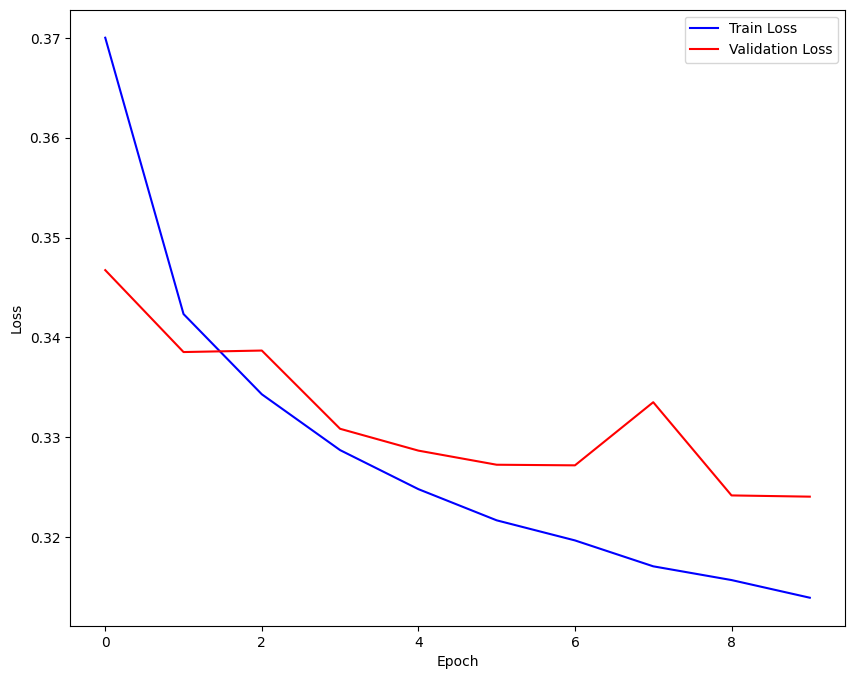

In [50]:
plt.figure(figsize=(10,8))

plt.plot(range(EPOCHS), history.history['loss'], color='b', label='Train Loss')
plt.plot(range(EPOCHS), history.history['val_loss'], color='r', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [52]:
print(f"Model Accuracy: {model.evaluate(X_test, y_test, verbose=0)[1]}")

Model Accuracy: 0.8585259318351746


In [53]:
y.sum() / len(y)

np.float64(0.22418121848473554)

In [55]:
y_pred = model.predict(X_test)

1334/1334 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [60]:
y_pred = np.array(list(map(lambda x: np.argmax(x), y_pred)))
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(42658,))

In [57]:
y_test

64882     0
96814     0
85767     0
73206     1
123872    0
         ..
130723    1
37025     1
131235    0
64878     0
138447    0
Name: RainTomorrow, Length: 42658, dtype: int64

In [61]:
print(f"Model F1 Score: {f1_score(y_test, y_pred)}")

Model F1 Score: 0.6403670818187236
